In [11]:
# CELL 1 - Load feature dataset + prep
import os
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/time_window_features.csv")
df["TransactionDT"] = pd.to_datetime(df["TransactionDT"])

os.makedirs("../reports", exist_ok=True)  # savefig fails if folder is missing

print(f"Loaded: {df.shape}")
df.head()

/var/folders/03/lp_c5nd95wvd8k80883y1h6w0000gn/T/ipykernel_20343/3373557867.py:6: DtypeWarning: Columns (45,46,47,49,50,51,52,53) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed/time_window_features.csv")


Loaded: (590540, 76)


,TransactionDT,TransactionAmt,customer_id,ProductCD,isFraud,card1,card2,card3,card4,card5,...,max_amt_7d,std_amt_7d,amount_dev_24h,amount_zscore_24h,no_prior_1h,no_prior_24h,single_prior_24h,hour,day_of_week,is_night_txn
0,1970-02-16 21:14:11,29.000,10000_111.0,W,0,10000,111.0,150.0,mastercard,117.0,...,0.000,0.000000,0.0000,0.000000,0,0,0,21,0,0
1,1970-04-01 17:57:56,42.777,10003_-1.0,C,0,10003,-1.0,NaN,NaN,NaN,...,0.000,0.000000,0.0000,0.000000,0,0,0,17,2,0
2,1970-04-08 11:23:35,39.394,10003_555.0,C,0,10003,555.0,128.0,visa,226.0,...,0.000,0.000000,0.0000,0.000000,0,0,0,11,2,0
3,1970-04-10 22:34:42,10.755,10003_555.0,C,0,10003,555.0,128.0,visa,226.0,...,39.394,0.000000,-28.6390,0.000000,0,0,1,22,4,0
4,1970-04-10 22:40:15,19.093,10003_555.0,C,0,10003,555.0,128.0,visa,226.0,...,39.394,20.250831,-5.9815,-0.295371,0,0,0,22,4,0


In [12]:
# CELL 2 - Velocity risk (defined ONCE, safe denominator)
# Share of the day's prior transactions concentrated in the last hour.
# clip(lower=1) prevents division by zero for first-time transactions
# (txn_count_24h == 0), which now exist in the dataset.
df["velocity_risk"] = (
    df["txn_count_1h"] / df["txn_count_24h"].clip(lower=1)
).clip(0, 1)

In [13]:
# CELL 3 - Class split + quick stats
fraud = df[df["isFraud"] == 1]
non_fraud = df[df["isFraud"] == 0]

print(df[["txn_count_1h", "txn_count_24h", "velocity_risk"]].describe().round(3))
print(f"\nFraud:     {len(fraud):,} ({len(fraud) / len(df):.2%})")
print(f"Non-fraud: {len(non_fraud):,}")

       txn_count_1h  txn_count_24h  velocity_risk
count    590540.000     590540.000     590540.000
mean          2.420         19.605          0.390
std           5.505         45.572          0.363
min           0.000          0.000          0.000
25%           1.000          2.000          0.100
50%           1.000          6.000          0.222
75%           2.000         20.000          0.600
max         192.000        881.000          1.000

Fraud:     20,663 (3.50%)
Non-fraud: 569,877


In [14]:
# CELL 4 - Plot helper (density + legend + safe save)
def plot_fraud_vs_legit(column, title, xlabel, bins=50, xlim=None, save_as=None):
    """Overlaid fraud vs non-fraud histograms.

    density=True is essential: fraud is ~3.5% of rows, so raw-count
    plots make the fraud distribution invisible. savefig runs BEFORE
    plt.show(), because show() clears the figure (blank-PNG bug).
    """
    plt.figure(figsize=(8, 4.5))
    plt.hist(non_fraud[column].dropna(), bins=bins, alpha=0.6,
             density=True, label="Non-fraud")
    plt.hist(fraud[column].dropna(), bins=bins, alpha=0.6,
             density=True, label="Fraud")
    if xlim:
        plt.xlim(*xlim)
    plt.xlabel(xlabel)
    plt.ylabel("Density")
    plt.title(title)
    plt.legend()
    if save_as:
        plt.savefig(save_as, dpi=150, bbox_inches="tight")
        print(f"Saved: {save_as}")
    plt.show()

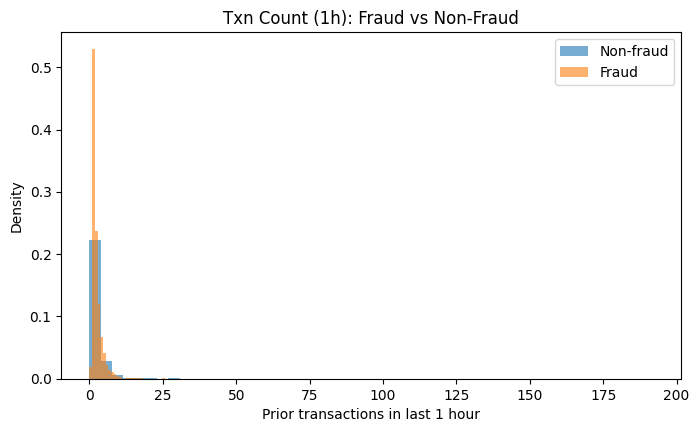

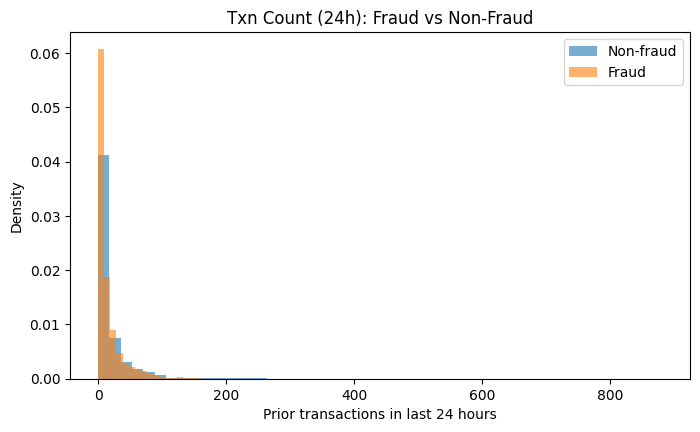

In [15]:
# CELL 5 - Velocity distributions
plot_fraud_vs_legit("txn_count_1h",
                    "Txn Count (1h): Fraud vs Non-Fraud",
                    "Prior transactions in last 1 hour")

plot_fraud_vs_legit("txn_count_24h",
                    "Txn Count (24h): Fraud vs Non-Fraud",
                    "Prior transactions in last 24 hours")

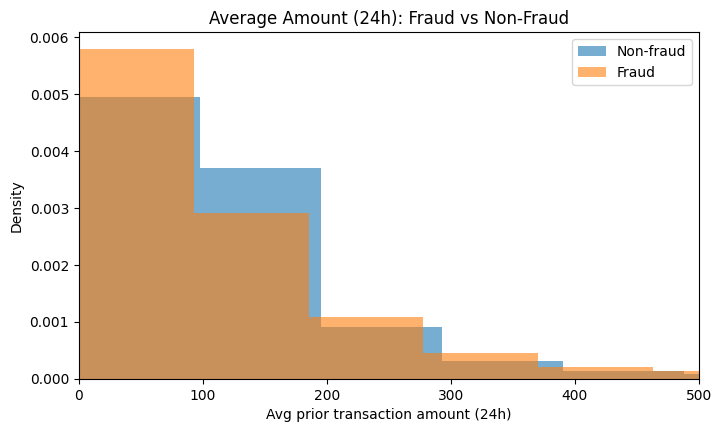

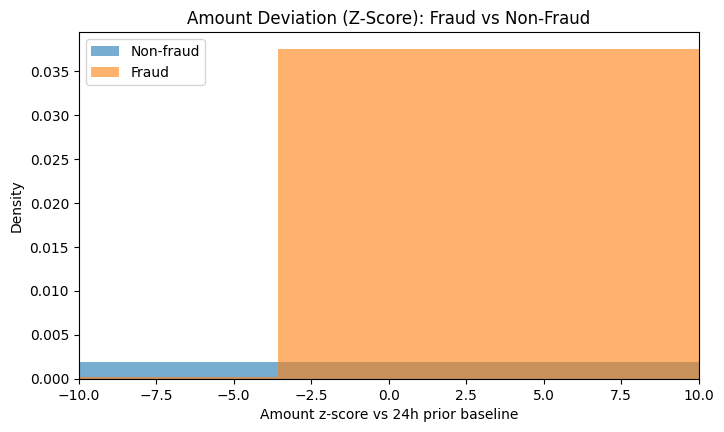

In [16]:
# CELL 6 - Spending behavior distributions
plot_fraud_vs_legit("avg_amt_24h",
                    "Average Amount (24h): Fraud vs Non-Fraud",
                    "Avg prior transaction amount (24h)",
                    xlim=(0, 500))   # right tail runs to ~4900; clip for readability

plot_fraud_vs_legit("amount_zscore_24h",
                    "Amount Deviation (Z-Score): Fraud vs Non-Fraud",
                    "Amount z-score vs 24h prior baseline",
                    bins=100, xlim=(-10, 10))

Saved: ../reports/velocity_vs_fraud.png


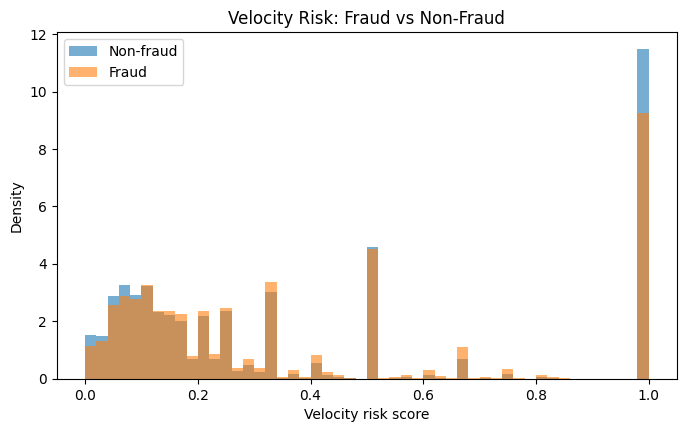

In [17]:
# CELL 7 - Velocity risk distribution (saved for README/report)
plot_fraud_vs_legit("velocity_risk",
                    "Velocity Risk: Fraud vs Non-Fraud",
                    "Velocity risk score",
                    save_as="../reports/velocity_vs_fraud.png")

is_night_txn
0    0.0347
1    0.0360
Name: isFraud, dtype: float64


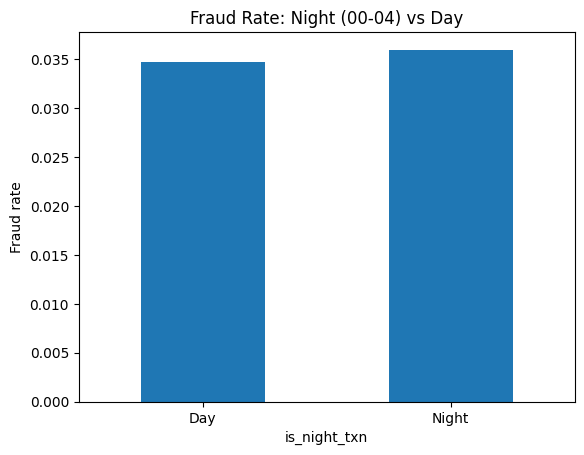

In [18]:
# CELL 8 - Night-time fraud rate
night_fraud_rate = df.groupby("is_night_txn")["isFraud"].mean()
print(night_fraud_rate.round(4))

ax = night_fraud_rate.plot(kind="bar",
                           title="Fraud Rate: Night (00-04) vs Day")
ax.set_xticklabels(["Day", "Night"], rotation=0)
plt.ylabel("Fraud rate")
plt.savefig("../reports/night_vs_day_fraud_rate.png", dpi=150,
            bbox_inches="tight")   # BEFORE show()
plt.show()

In [19]:
# CELL 9 - Summary table: feature means by class
# (works with old AND new feature CSVs - checks which columns exist)
candidates = [
    "txn_count_1h", "txn_count_24h", "velocity_risk",
    "avg_amt_24h", "amount_zscore_24h", "is_night_txn",
    "no_prior_24h", "single_prior_24h",
]
check_cols = [c for c in candidates if c in df.columns]

summary = df.groupby("isFraud")[check_cols].mean().round(3)
summary.index = ["Non-fraud", "Fraud"]
print(summary)

           txn_count_1h  txn_count_24h  velocity_risk  avg_amt_24h  \
Non-fraud         2.426         19.738          0.391      130.425   
Fraud             2.281         15.921          0.375      126.312   

           amount_zscore_24h  is_night_txn  no_prior_24h  single_prior_24h  
Non-fraud              0.886         0.225           0.0              0.20  
Fraud                  0.831         0.231           0.0              0.14  


In [20]:
# CELL 10 - Save dataset WITH velocity_risk for modeling notebooks
df.to_csv("../data/processed/time_window_features.csv", index=False)
print(f"Saved with velocity_risk: {df.shape}")

Saved with velocity_risk: (590540, 77)
